In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option('display.max_columns', 60)

In [3]:
go = pd.read_csv("../data/go_annotations_raw.csv", low_memory=False)

EXPERIMENTAL = {'EXP','IDA','IPI','IMP','IGI','IEP',
                'HTP','HDA','HMP','HGI','HEP'}     # standard experimental codes
go_exp = go[go['Evidence_Code'].isin(EXPERIMENTAL)].copy()
print(f"Annotations after experimental-evidence filter: {len(go_exp)} (from {len(go)})")
print("Proteins surviving with ≥1 experimental annotation:",
      go_exp['DB_Object_ID'].nunique())
print("\nAspect distribution after filter:")
print(go_exp['Aspect'].value_counts())

go_exp.to_csv("../data/go_annotations_experimental.csv", index=False)

Annotations after experimental-evidence filter: 76902 (from 129684)
Proteins surviving with ≥1 experimental annotation: 1266

Aspect distribution after filter:
Aspect
F    53949
P    11877
C    11076
Name: count, dtype: int64


In [4]:
import requests
from goatools.obo_parser import GODag
from goatools.mapslim import mapslim

# Download GO and GO Slim ontology files
for path, url in [
    ("../data/go.obo", "https://current.geneontology.org/ontology/go.obo"),
    ("../data/goslim_generic.obo", "https://current.geneontology.org/ontology/subsets/goslim_generic.obo"),
]:
    print(f"Downloading {url} ...")
    r = requests.get(url, timeout=180, headers={"User-Agent": "Mozilla/5.0"})
    r.raise_for_status()
    with open(path, "wb") as f:
        f.write(r.content)
    print(f"  Saved {len(r.content)/1e6:.1f} MB to {path}")

print("\nLoading GO DAG (this takes ~10-20 seconds) ...")
godag = GODag("../data/go.obo")
print("Loading GO Slim DAG ...")
slimdag = GODag("../data/goslim_generic.obo")

def slim_terms_for(gid):
    try:
        direct, ancestors = mapslim(gid, godag, slimdag)
        return list(direct | ancestors)
    except Exception:
        return []

print("\nMapping annotations to slim terms ...")
go_exp['slim_terms'] = go_exp['GO_ID'].apply(slim_terms_for)

exploded = (go_exp.explode('slim_terms')[['DB_Object_ID','slim_terms','Aspect']]
                  .dropna()
                  .rename(columns={'DB_Object_ID':'acc','slim_terms':'slim_term','Aspect':'aspect'}))

for letter, name in [('P','BP'), ('F','MF'), ('C','CC')]:
    sub = exploded[exploded['aspect']==letter]
    mat = (sub.assign(v=1)
              .pivot_table(index='acc', columns='slim_term', values='v', fill_value=0)
              .astype('int8'))
    mat.to_csv(f"../data/features_GO_{name}_slim.csv")
    print(f"  {name}: {mat.shape[0]} proteins × {mat.shape[1]} slim terms")

  Saved 36.7 MB to ../data/go.obo
  Saved 0.1 MB to ../data/goslim_generic.obo

Loading GO DAG (this takes ~10-20 seconds) ...
../data/go.obo: fmt(1.2) rel(2026-05-19) 41,552 Terms
Loading GO Slim DAG ...
../data/goslim_generic.obo: fmt(1.2) rel(go/2026-05-19/subsets/goslim_generic.owl) 206 Terms

Mapping annotations to slim terms ...
  BP: 866 proteins × 64 slim terms
  MF: 1014 proteins × 36 slim terms
  CC: 1120 proteins × 25 slim terms


In [5]:
# Reload the full disprot table (we're in notebook 02 — no shared kernel state)
disprot = pd.read_csv("../data/disprot.tsv", sep='\t', low_memory=False)
disprot = disprot.rename(columns={
    'UniProt ACC':'acc', 'DisProt ID':'disprot_id', 'Protein name':'name',
    'Gene name':'gene_name', 'Sequence length':'length', 'Organism':'organism',
    'NCBI Taxon ID':'ncbi_taxon_id', 'Protein Disorder Content':'disorder_content',
    'Region ID':'region_id', 'Start':'start', 'End':'end',
    'Term namespace':'term_namespace', 'Term ID':'term', 'Term name':'term_name',
    'ECO Term ID':'ec', 'ECO Term name':'ec_name', 'PMID':'pmid',
    'Region sequence':'region_sequence',
    'Alphafold Very Low confidence content':'alphafold_lc',
    'Obsolete':'obsolete', 'Dataset':'dataset',
})
disprot['acc'] = disprot['acc'].str.split('-').str[0]

# 1) Final label distribution
labels = pd.read_csv("../data/labels.csv")
print("=== Label distribution ===")
print(labels['d2o'].value_counts())
print(f"Total: {len(labels)}, positives: {labels['d2o'].sum()}, "
      f"positive rate: {labels['d2o'].mean():.1%}\n")

# 2) Of positives, how many are ONLY d2o vs mixed with other transition types
human_trans = disprot[(disprot['organism']=='Homo sapiens') &
                      (disprot['term_namespace']=='Structural transition')]
positive_accs = set(labels[labels['d2o']==1]['acc'])
pos_trans = human_trans[human_trans['acc'].isin(positive_accs)]
per_protein_terms = pos_trans.groupby('acc')['term_name'].unique()
only_d2o = (per_protein_terms.apply(lambda x: set(x) == {'disorder to order'})).sum()
mixed = (per_protein_terms.apply(lambda x: 'disorder to order' in x and len(set(x)) > 1)).sum()
print("=== Positives: transition profile ===")
print(f"Positives with ONLY 'disorder to order': {only_d2o}")
print(f"Positives with d2o + other transition(s): {mixed}\n")

# 3) Short-region check
d2o_regions = disprot[(disprot['organism']=='Homo sapiens') &
                      (disprot['term']=='IDPO:0000011')].copy()
d2o_regions['region_len'] = d2o_regions['end'] - d2o_regions['start'] + 1
print("=== D2o region length distribution ===")
print(d2o_regions['region_len'].describe())
short = d2o_regions[d2o_regions['region_len'] < 5]
print(f"\nRegions shorter than 5 residues: {len(short)}")

=== Label distribution ===
d2o
0    1091
1     188
Name: count, dtype: int64
Total: 1279, positives: 188, positive rate: 14.7%

=== Positives: transition profile ===
Positives with ONLY 'disorder to order': 179
Positives with d2o + other transition(s): 9

=== D2o region length distribution ===
count    299.000000
mean      53.431438
std       70.024285
min       10.000000
25%       15.000000
50%       26.000000
75%       63.000000
max      454.000000
Name: region_len, dtype: float64

Regions shorter than 5 residues: 0


In [6]:
clusters = {}
current = None
with open("../data/sequences_nr40.fasta.clstr") as f:
    for line in f:
        if line.startswith(">Cluster"):
            current = int(line.strip().split()[1])
        else:
            acc = line.split(">")[1].split("|")[1] if "|" in line else line.split(">")[1].split("...")[0]
            clusters[acc] = current

cl_df = pd.Series(clusters, name='cluster').rename_axis('acc').reset_index()
cl_df.to_csv("../data/clusters.csv", index=False)
print(f"Distinct clusters: {cl_df['cluster'].nunique()} (from {len(cl_df)} proteins)")
print(f"\nCluster size distribution:")
print(cl_df.groupby('cluster').size().describe())

Distinct clusters: 1168 (from 1279 proteins)

Cluster size distribution:
count    1168.000000
mean        1.095034
std         0.359056
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         4.000000
dtype: float64


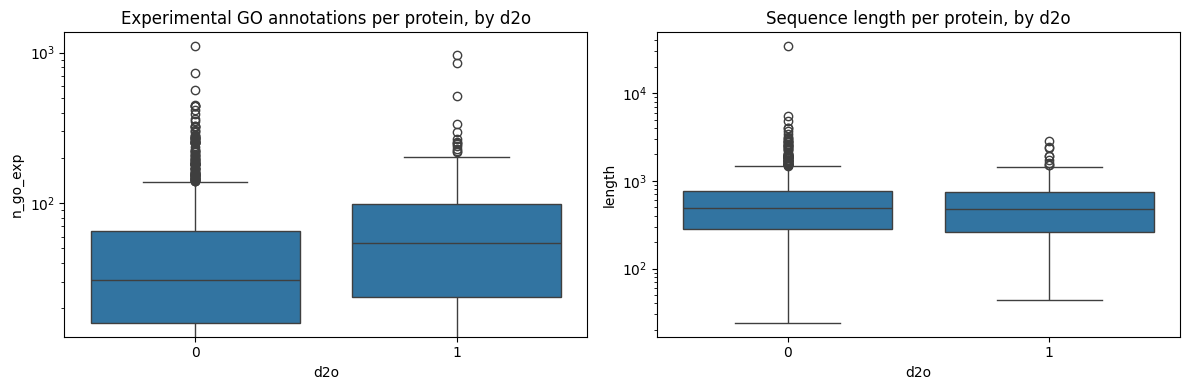

    n_go_exp                                                          length  \
       count       mean         std  min    25%   50%    75%     max   count   
d2o                                                                            
0     1091.0  56.103575   76.156317  0.0  16.00  31.0  65.50  1104.0  1091.0   
1      188.0  83.473404  112.730450  0.0  23.75  54.5  98.25   964.0   188.0   

                                                                  
           mean          std   min    25%    50%    75%      max  
d2o                                                               
0    657.115490  1159.722930  24.0  282.5  484.0  765.5  34350.0  
1    569.090426   447.746511  44.0  260.5  475.0  746.5   2843.0  


In [7]:
import os, seaborn as sns
os.makedirs("../results/figures", exist_ok=True)

master = (pd.read_csv("../data/labels.csv")
            .merge(pd.read_csv("../data/sequences.csv")[['acc','length']], on='acc', how='left')
            .merge(go_exp.groupby('DB_Object_ID').size()
                         .rename('n_go_exp').reset_index()
                         .rename(columns={'DB_Object_ID':'acc'}),
                   on='acc', how='left'))
master['n_go_exp'] = master['n_go_exp'].fillna(0).astype(int)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=master, x='d2o', y='n_go_exp', ax=ax[0])
ax[0].set_yscale('log'); ax[0].set_title("Experimental GO annotations per protein, by d2o")
sns.boxplot(data=master, x='d2o', y='length', ax=ax[1])
ax[1].set_yscale('log'); ax[1].set_title("Sequence length per protein, by d2o")
plt.tight_layout()
plt.savefig("../results/figures/annotation_bias.png", dpi=150)
plt.show()

print(master.groupby('d2o')[['n_go_exp','length']].describe())